In [3]:
import sys 
sys.path.append('../SRC')
from data_loader import load_data


In [4]:
path = '../Data/Raw/final_data.csv'
df = load_data(path)
df.head()


,Company_Name,Class,Designation,Location,Total_applicants,LinkedIn_Followers,Level,Involvement,Employee_count,Industry,...,REACTJS,AI,UI,TABLEAU,NODEJS,EXCEL,POWER BI,SELENIUM,HTML,ML
0,Wipro,Class 3,Project Manager,Maharashtra,0,6737300,Full-time,Entry level,10001,IT Services and IT Consulting,...,0,1,1,0,0,1,0,0,0,1
1,Wipro,Class 3,Project Manager,Delhi,121,6737300,Full-time,Entry level,10001,IT Services and IT Consulting,...,0,1,1,0,0,1,0,0,0,1
2,Wipro,Class 3,Project Manager,Delhi,0,6737300,Full-time,Entry level,10001,IT Services and IT Consulting,...,0,1,1,0,0,1,0,0,0,1
3,Wipro,Class 3,Administrator,Telangana,0,6737300,Full-time,Mid-Senior level,10001,IT Services and IT Consulting,...,0,1,1,0,0,1,0,0,0,0
4,Wipro,Class 3,Project Manager,Maharashtra,119,6737300,Full-time,Entry level,10001,IT Services and IT Consulting,...,0,1,1,0,0,1,0,0,0,1


In [5]:
skills = df.columns[df.isin([0, 1]).all()]
print("Skills columns:", skills)

skills_count = df[skills].sum().sort_values(ascending=False)
top_skills = skills_count.head(10)  

print(skills_count) 

Skills columns: Index(['PYTHON', 'C++', 'JAVA', 'HADOOP', 'SCALA', 'FLASK', 'PANDAS', 'SPARK',
       'NUMPY', 'PHP', 'SQL', 'MYSQL', 'CSS', 'MONGODB', 'NLTK', 'TENSORFLOW',
       'LINUX', 'RUBY', 'JAVASCRIPT', 'DJANGO', 'REACT', 'REACTJS', 'AI', 'UI',
       'TABLEAU', 'NODEJS', 'EXCEL', 'POWER BI', 'SELENIUM', 'HTML', 'ML'],
      dtype='object')
AI            704
UI            672
EXCEL         236
SQL           192
JAVA          167
ML            148
SCALA         140
HTML           90
CSS            83
PYTHON         76
JAVASCRIPT     73
REACT          38
LINUX          30
MONGODB        28
MYSQL          28
NODEJS         26
C++            26
HADOOP         22
SPARK          20
FLASK          18
DJANGO         16
POWER BI       15
TABLEAU        15
RUBY           11
SELENIUM       11
PHP            11
REACTJS        10
NLTK            3
NUMPY           3
PANDAS          3
TENSORFLOW      1
dtype: int64


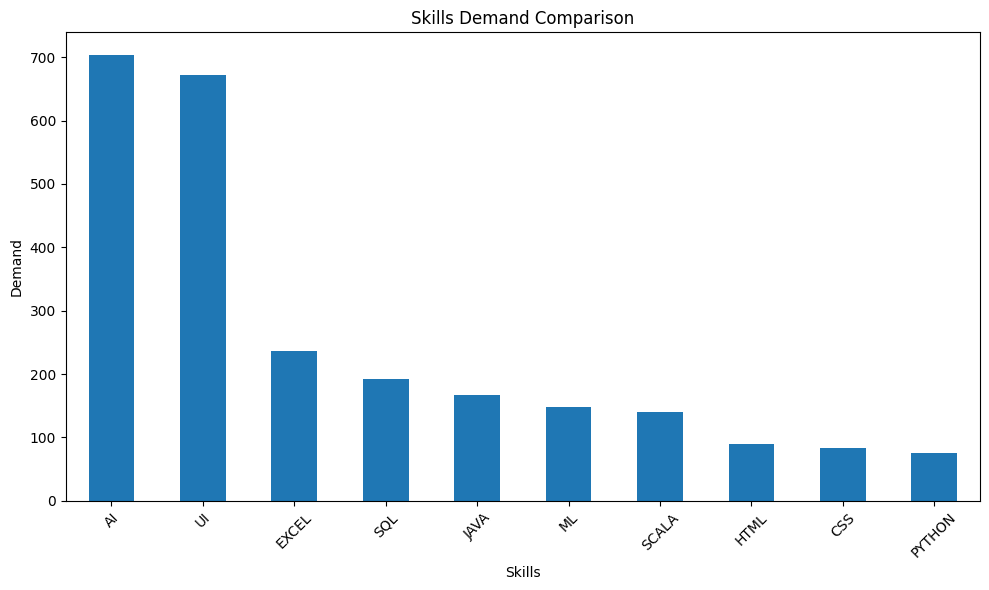

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
top_skills.plot(kind='bar')
plt.title('Skills Demand Comparison')
plt.xlabel('Skills')
plt.ylabel('Demand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
data_related_jobs = df[df['Designation'].str.contains('Data', case=False, na=False)]
print(data_related_jobs['Designation'].unique())

['AI/ML - Data Scientist' 'Big Data Developer' 'Data Analytics Architect'
 'Opening for Database Developer' 'SAP Data Specialist' 'Data Modeler'
 'SAP ABAP OData' 'Database Admin. Sr Cnslt.' 'Data Architect'
 'SAP ABAP For NTT DATA' 'Data Analyst (Business professional Institute)'
 'Associate Consultant - Data Migration'
 'Hiring for Associate Consultant- Data Migration with a MNC Pharmaceutical Firm'
 'Big Data Engineer - WFH' 'Data Scientist- WFH'
 'Data Solutions Architect' 'Data Engineering Expert - WFH'
 'Data Engineer' 'Lead Data Engineer' 'Lead Data Engineer - WFH'
 'Database Engineer' 'Senior - Data Engineer']


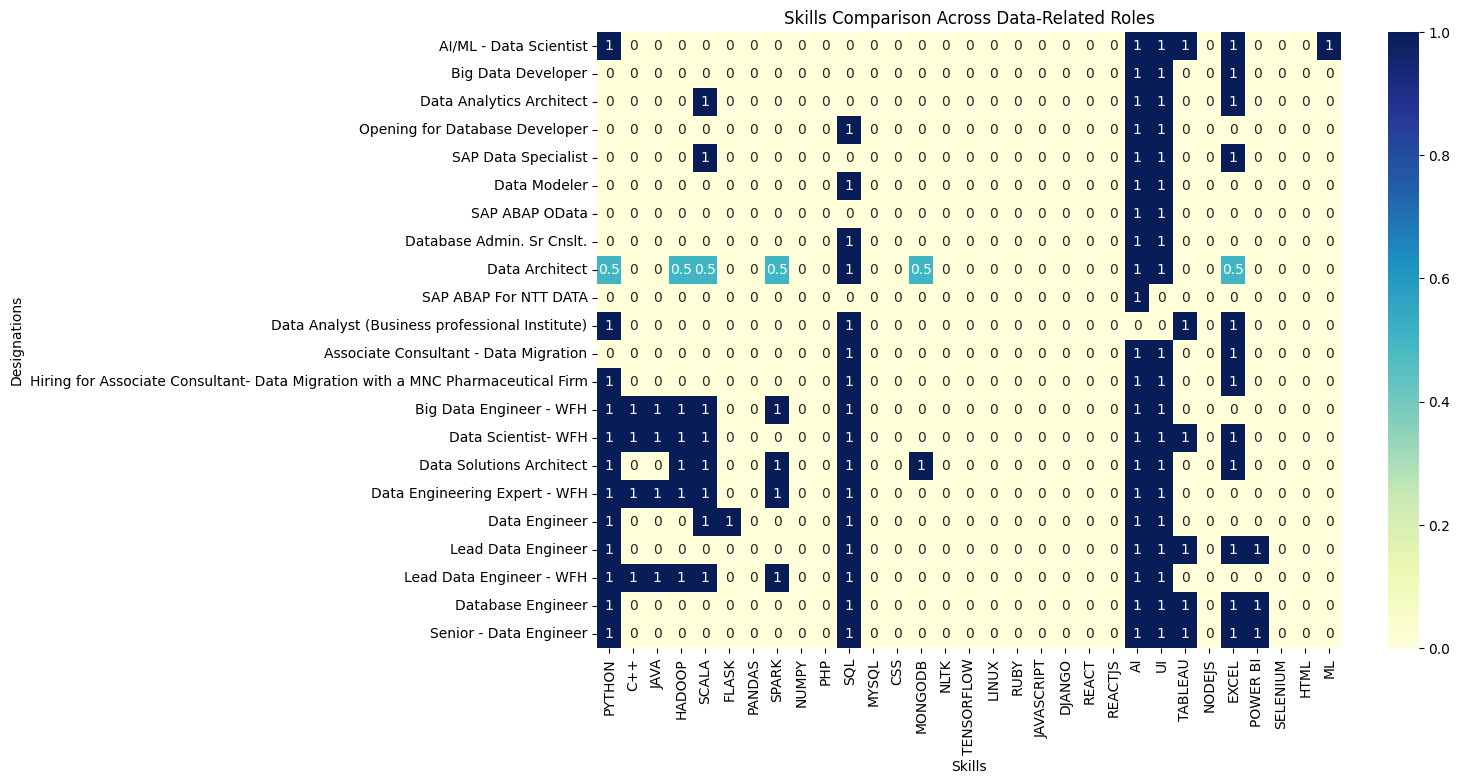

In [20]:
role_skills = df.groupby('Designation')[skills].mean()


import seaborn as sns

heatmap = role_skills.loc[data_related_jobs['Designation'].unique()]
plt.figure(figsize=(12,8))
sns.heatmap(heatmap, annot=True, cmap='YlGnBu')
plt.title('Skills Comparison Across Data-Related Roles')
plt.xlabel('Skills')
plt.ylabel('Designations')
plt.show()